In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Find project root whether notebook starts in root or notebooks/
cwd = Path.cwd()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not locate project root.")

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_CSV = DATA_DIR / "train.csv"
IMAGE_DIR = DATA_DIR / "train_images"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("CSV:", TRAIN_CSV)
print("Images:", IMAGE_DIR)

Project root: c:\Users\test\Documents\EEEM068_LSA_Melanoma
CSV: c:\Users\test\Documents\EEEM068_LSA_Melanoma\data\train.csv
Images: c:\Users\test\Documents\EEEM068_LSA_Melanoma\data\train_images


In [2]:
df = pd.read_csv(TRAIN_CSV)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (33126, 11)


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,tfrecord,width,height
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,0,6000,4000
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,0,6000,4000
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,6,1872,1053
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0,0,1872,1053
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0,11,6000,4000


In [4]:
print("Columns:")
for col in df.columns:
    print("-", col)

required_columns = [
    "image_name",
    "patient_id",
    "target"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing required columns:", missing_required)

Columns:
- image_name
- patient_id
- sex
- age_approx
- anatom_site_general_challenge
- diagnosis
- benign_malignant
- target
- tfrecord
- width
- height
Missing required columns: []


In [6]:
print("Rows:", len(df))
print("Unique image names:", df["image_name"].nunique())
print("Duplicate image names:", df["image_name"].duplicated().sum())

print("\nTarget values:")
print(df["target"].value_counts(dropna=False))

print("\nTarget missing values:")
print(df["target"].isna().sum())

assert df["image_name"].duplicated().sum() == 0
assert df["target"].isna().sum() == 0
assert set(df["target"].unique()).issubset({0, 1})

print("Basic integrity checks passed.")

Rows: 33126
Unique image names: 33126
Duplicate image names: 0

Target values:
target
0    32542
1      584
Name: count, dtype: int64

Target missing values:
0
Basic integrity checks passed.


In [7]:
n_total = len(df)
n_positive = int((df["target"] == 1).sum())
n_negative = int((df["target"] == 0).sum())

positive_rate = n_positive / n_total
imbalance_ratio = n_negative / n_positive

print(f"Total images: {n_total:,}")
print(f"Benign (0): {n_negative:,}")
print(f"Melanoma (1): {n_positive:,}")
print(f"Melanoma prevalence: {positive_rate:.4%}")
print(f"Negative:positive ratio: {imbalance_ratio:.2f}:1")

Total images: 33,126
Benign (0): 32,542
Melanoma (1): 584
Melanoma prevalence: 1.7630%
Negative:positive ratio: 55.72:1


In [9]:
n_patients = df["patient_id"].nunique(dropna=True)
missing_patients = int(df["patient_id"].isna().sum())

print(f"Unique known patients: {n_patients:,}")
print(f"Rows with missing patient_id: {missing_patients:,}")

patient_counts = (
    df.dropna(subset=["patient_id"])
      .groupby("patient_id")
      .size()
      .sort_values(ascending=False)
)

display(patient_counts.describe())

Unique known patients: 2,056
Rows with missing patient_id: 0


count    2056.000000
mean       16.111868
std        15.674491
min         2.000000
25%         5.000000
50%        12.000000
75%        22.000000
max       115.000000
dtype: float64

In [10]:
metadata_columns = [
    col for col in [
        "sex",
        "age_approx",
        "anatom_site_general_challenge"
    ]
    if col in df.columns
]

missing_summary = pd.DataFrame({
    "missing_count": df[metadata_columns].isna().sum(),
    "missing_percent": (
        df[metadata_columns].isna().mean() * 100
    )
})

display(missing_summary)

,missing_count,missing_percent
sex,65,0.196220
age_approx,68,0.205277
anatom_site_general_challenge,527,1.590895


In [11]:
df["image_path"] = df["image_name"].apply(
    lambda name: IMAGE_DIR / f"{name}.jpg"
)

exists = df["image_path"].apply(Path.exists)

print("Images found:", int(exists.sum()))
print("Images missing:", int((~exists).sum()))

Images found: 33126
Images missing: 0


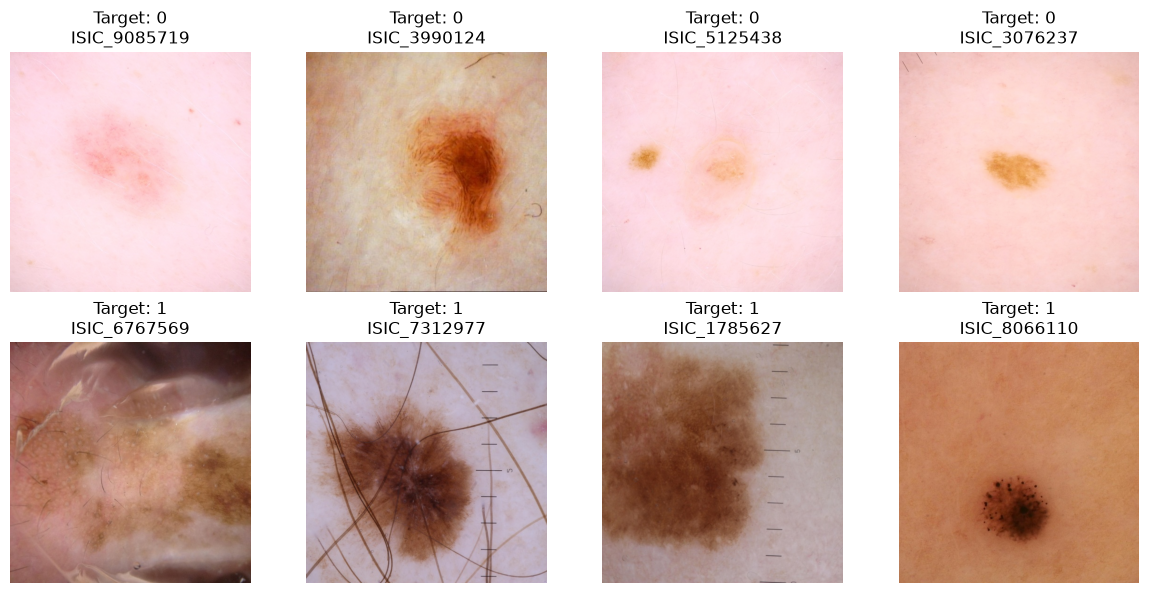

In [12]:
benign_samples = df[df["target"] == 0].sample(
    n=min(4, (df["target"] == 0).sum()),
    random_state=42
)

melanoma_samples = df[df["target"] == 1].sample(
    n=min(4, (df["target"] == 1).sum()),
    random_state=42
)

samples = pd.concat([
    benign_samples,
    melanoma_samples
])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(
        f"Target: {row['target']}\n{row['image_name']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

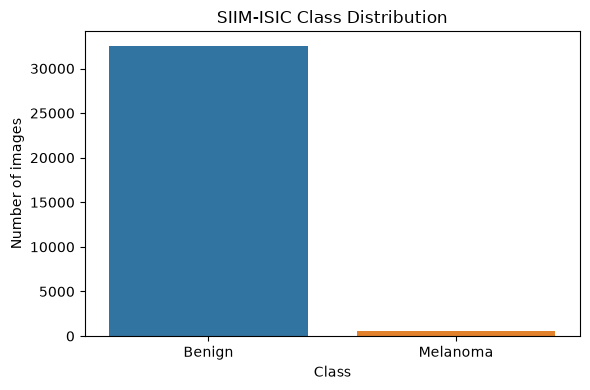

Saved: c:\Users\test\Documents\EEEM068_LSA_Melanoma\outputs\figures\class_distribution.png


In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target",
    hue="target",
    legend=False
)

plt.xticks([0, 1], ["Benign", "Melanoma"])
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("SIIM-ISIC Class Distribution")

plt.tight_layout()

output_path = FIGURE_DIR / "class_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

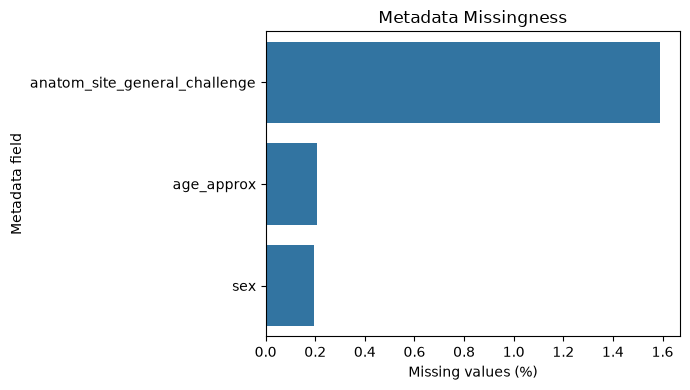

Saved: c:\Users\test\Documents\EEEM068_LSA_Melanoma\outputs\figures\metadata_missingness.png


In [14]:
if metadata_columns:
    missing_percentages = (
        df[metadata_columns]
        .isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(7, 4))

    sns.barplot(
        x=missing_percentages.values,
        y=missing_percentages.index
    )

    plt.xlabel("Missing values (%)")
    plt.ylabel("Metadata field")
    plt.title("Metadata Missingness")

    plt.tight_layout()

    output_path = FIGURE_DIR / "metadata_missingness.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

In [16]:
if "sex" in df.columns:
    sex_summary = (
        df.groupby("sex", dropna=False)["target"]
          .agg(["count", "sum", "mean"])
          .rename(columns={
              "count": "images",
              "sum": "melanoma_cases",
              "mean": "melanoma_rate"
          })
    )

    display(sex_summary)

if "anatom_site_general_challenge" in df.columns:
    site_summary = (
        df.groupby(
            "anatom_site_general_challenge",
            dropna=False
        )["target"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "images",
            "sum": "melanoma_cases",
            "mean": "melanoma_rate"
        })
        .sort_values("melanoma_rate", ascending=False)
    )

    display(site_summary)

,images,melanoma_cases,melanoma_rate
sex,,,
female,15981,220,0.013766
male,17080,364,0.021311
NaN,65,0,0.000000


,images,melanoma_cases,melanoma_rate
anatom_site_general_challenge,,,
head/neck,1855,74,0.039892
oral/genital,124,4,0.032258
upper extremity,4983,111,0.022276
NaN,527,9,0.017078
torso,16845,257,0.015257
lower extremity,8417,124,0.014732
palms/soles,375,5,0.013333


In [18]:
dataset_summary = {
    "total_images": int(n_total),
    "benign_images": int(n_negative),
    "melanoma_images": int(n_positive),
    "melanoma_prevalence": float(positive_rate),
    "negative_positive_ratio": float(imbalance_ratio),
    "unique_known_patients": int(n_patients),
    "missing_patient_ids": int(missing_patients),
    "missing_images": int((~exists).sum()),
    "metadata_missing_counts": {
        col: int(df[col].isna().sum())
        for col in metadata_columns
    }
}

summary_path = (
    PROJECT_ROOT
    / "outputs"
    / "dataset_summary.json"
)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(dataset_summary, f, indent=2)

print(json.dumps(dataset_summary, indent=2))
print("\nSaved:", summary_path)

{
  "total_images": 33126,
  "benign_images": 32542,
  "melanoma_images": 584,
  "melanoma_prevalence": 0.01762965646320111,
  "negative_positive_ratio": 55.72260273972603,
  "unique_known_patients": 2056,
  "missing_patient_ids": 0,
  "missing_images": 0,
  "metadata_missing_counts": {
    "sex": 65,
    "age_approx": 68,
    "anatom_site_general_challenge": 527
  }
}

Saved: c:\Users\test\Documents\EEEM068_LSA_Melanoma\outputs\dataset_summary.json


In [19]:
from src.splits import create_patient_folds

fold_df = create_patient_folds(
    df,
    n_splits=5,
    seed=42
)

print(
    fold_df["fold"]
    .value_counts()
    .sort_index()
)

fold
0    6627
1    6625
2    6621
3    6628
4    6625
Name: count, dtype: int64


In [20]:
fold_summary = (
    fold_df.groupby("fold")["target"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "images",
        "sum": "melanoma_cases",
        "mean": "melanoma_rate"
    })
)

display(fold_summary)

,images,melanoma_cases,melanoma_rate
fold,,,
0,6627,117,0.017655
1,6625,116,0.017509
2,6621,116,0.017520
3,6628,117,0.017652
4,6625,118,0.017811


In [21]:
VALIDATION_FOLD = 0

train_df = fold_df[
    fold_df["fold"] != VALIDATION_FOLD
].copy()

val_df = fold_df[
    fold_df["fold"] == VALIDATION_FOLD
].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining class distribution:")
print(
    train_df["target"]
    .value_counts()
    .sort_index()
)

print("\nValidation class distribution:")
print(
    val_df["target"]
    .value_counts()
    .sort_index()
)

Training images: 26499
Validation images: 6627

Training class distribution:
target
0    26032
1      467
Name: count, dtype: int64

Validation class distribution:
target
0    6510
1     117
Name: count, dtype: int64


In [22]:
train_patients = set(
    train_df["patient_id"].dropna()
)

val_patients = set(
    val_df["patient_id"].dropna()
)

overlap = train_patients.intersection(
    val_patients
)

print("Known patient overlap:", len(overlap))

assert len(overlap) == 0

print("Patient leakage check passed.")

Known patient overlap: 0
Patient leakage check passed.


In [23]:
fold_manifest = fold_df[
    ["image_name", "fold"]
].copy()

fold_path = DATA_DIR / "train_folds.csv"

fold_manifest.to_csv(
    fold_path,
    index=False
)

print("Saved:", fold_path)
print("Rows:", len(fold_manifest))

Saved: c:\Users\test\Documents\EEEM068_LSA_Melanoma\data\train_folds.csv
Rows: 33126


In [24]:
saved_folds = pd.read_csv(
    DATA_DIR / "train_folds.csv"
)

reproduced = df.merge(
    saved_folds,
    on="image_name",
    how="left",
    validate="one_to_one"
)

print(
    "Missing fold assignments:",
    reproduced["fold"].isna().sum()
)

assert reproduced["fold"].isna().sum() == 0

print("Fold manifest verified.")

Missing fold assignments: 0
Fold manifest verified.
